# PnLCalib para homografia y bird-eye del campo

Este notebook prueba un tercer enfoque, separado del clásico y del de Soccana, usando [`PnLCalib`](https://github.com/mguti97/PnLCalib).

Flujo:
- clonar el repo de `PnLCalib` si no existe localmente;
- descargar los pesos `SV_kp` y `SV_lines` desde GitHub Releases;
- detectar keypoints y líneas del campo en cada frame broadcast;
- estimar homografía `imagen -> campo` y hacer warp a bird-eye;
- proyectar tracks al campo 2D para validar si la transformación es usable.

Nota: `PnLCalib` usa licencia `GPL-2.0`; si luego quieres integrarlo en producto cerrado, hay que revisar esa implicación.


In [1]:
from pathlib import Path
import importlib
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontro config.yaml al subir desde el notebook.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

module_name = "experiments.reference_points.pnlcalib_reference_points"
sys.modules.pop(module_name, None)
pnl_module = importlib.import_module(module_name)

PitchGeometry = pnl_module.PitchGeometry
StreamingPnLCalibEstimator = pnl_module.StreamingPnLCalibEstimator
blend_birdeye_with_template = pnl_module.blend_birdeye_with_template
ensure_pnlcalib_repo = pnl_module.ensure_pnlcalib_repo
ensure_pnlcalib_weights = pnl_module.ensure_pnlcalib_weights
extract_track_ground_points = pnl_module.extract_track_ground_points
find_project_root = pnl_module.find_project_root
get_default_pnlcalib_repo_path = pnl_module.get_default_pnlcalib_repo_path
get_default_pnlcalib_weight_paths = pnl_module.get_default_pnlcalib_weight_paths
get_missing_pnlcalib_modules = pnl_module.get_missing_pnlcalib_modules
get_video_frame_count = pnl_module.get_video_frame_count
get_video_frame_size = pnl_module.get_video_frame_size
iterate_video_frames = pnl_module.iterate_video_frames
load_default_video_path = pnl_module.load_default_video_path
load_pnlcalib_runtime = pnl_module.load_pnlcalib_runtime
load_tracks_json = pnl_module.load_tracks_json
overlay_pnlcalib_detections = pnl_module.overlay_pnlcalib_detections
points_inside_field_mask = pnl_module.points_inside_field_mask
project_image_points = pnl_module.project_image_points
render_projected_tracks_birdeye = pnl_module.render_projected_tracks_birdeye
rescale_track_points = pnl_module.rescale_track_points
resize_frame = pnl_module.resize_frame
save_sequence_summary = pnl_module.save_sequence_summary
warp_frame_to_birdeye = pnl_module.warp_frame_to_birdeye

PROJECT_ROOT = find_project_root(PROJECT_ROOT)

def bgr_to_rgb(image_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

PROJECT_ROOT


PosixPath('/Users/carloscole/narrador-futbol')

In [2]:
VIDEO_PATH = load_default_video_path(PROJECT_ROOT)
REPO_PATH = get_default_pnlcalib_repo_path(PROJECT_ROOT)
WEIGHTS_KP_PATH, WEIGHTS_LINE_PATH = get_default_pnlcalib_weight_paths(PROJECT_ROOT)
TRACKS_PATH = PROJECT_ROOT / "output" / "tracks_json" / "tracker" / "tracks.json"
SUMMARY_JSON_PATH = PROJECT_ROOT / "output" / "reference_points" / "pnlcalib_sequence_summary.json"

FIELD_LENGTH_M = 106.0
FIELD_WIDTH_M = 68.0
PIXELS_PER_METER = 8
MAX_WIDTH = 1280
TRACK_GROUND_BOTTOM_OFFSET_RATIO = 0.04
START_FRAME = 0
FRAME_STEP = 1
TOTAL_FRAMES = get_video_frame_count(VIDEO_PATH)
ORIGINAL_FRAME_WIDTH, ORIGINAL_FRAME_HEIGHT = get_video_frame_size(VIDEO_PATH)
SEARCH_END_FRAME = min(TOTAL_FRAMES - 1, 100)
END_FRAME = SEARCH_END_FRAME

KEYPOINT_THRESHOLD = 0.3434
LINE_THRESHOLD = 0.7867
PNL_REFINE = True
TEMPORAL_BLEND = 0.20
VISUALIZE_FRAME_INDEX = None
SAVE_SEQUENCE_JSON = False
PREFER_FRAMES_WITH_TRACKS = True
MIN_PROJECTED_PERSONS_IN_FIELD = 13  # En el video de prueba, PnLCalib estabiliza 13/22 dentro del campo.
FIELD_MARGIN_M = 2.0
STOP_AT_FIRST_VALID_FRAME = True

geometry = PitchGeometry(field_length_m=FIELD_LENGTH_M, field_width_m=FIELD_WIDTH_M)
missing_modules = get_missing_pnlcalib_modules()
tracks_data = load_tracks_json(TRACKS_PATH) if TRACKS_PATH.exists() else None

person_track_counts = {}
if tracks_data is not None:
    max_frames_tracks = max(
        len(tracks_data.get("player", [])),
        len(tracks_data.get("goalkeeper", [])),
        len(tracks_data.get("referee", [])),
    )
    for frame_idx in range(max_frames_tracks):
        total_people = 0
        for class_name in ("player", "goalkeeper", "referee"):
            class_frames = tracks_data.get(class_name, [])
            if frame_idx < len(class_frames):
                total_people += len(class_frames[frame_idx])
        person_track_counts[frame_idx] = total_people

display(
    pd.Series(
        {
            "video_path": str(VIDEO_PATH),
            "repo_path": str(REPO_PATH),
            "weights_kp_path": str(WEIGHTS_KP_PATH),
            "weights_line_path": str(WEIGHTS_LINE_PATH),
            "field_length_m": FIELD_LENGTH_M,
            "field_width_m": FIELD_WIDTH_M,
            "original_frame_size": f"{ORIGINAL_FRAME_WIDTH}x{ORIGINAL_FRAME_HEIGHT}",
            "keypoint_threshold": KEYPOINT_THRESHOLD,
            "line_threshold": LINE_THRESHOLD,
            "pnl_refine": PNL_REFINE,
            "track_ground_bottom_offset_ratio": TRACK_GROUND_BOTTOM_OFFSET_RATIO,
            "tracks_json_exists": TRACKS_PATH.exists(),
            "frames_search_start": START_FRAME,
            "frames_search_end": END_FRAME,
        }
    ).to_frame("value")
)

if missing_modules:
    display(pd.Series(missing_modules).to_frame("pip_package"))


,value
video_path,/Users/carloscole/narrador-futbol/data/partido...
repo_path,/Users/carloscole/narrador-futbol/models/refer...
weights_kp_path,/Users/carloscole/narrador-futbol/models/refer...
weights_line_path,/Users/carloscole/narrador-futbol/models/refer...
field_length_m,106.0
field_width_m,68.0
keypoint_threshold,0.3434
line_threshold,0.7867
pnl_refine,True
tracks_json_exists,True


In [3]:
if missing_modules:
    raise ImportError(
        "Faltan dependencias para PnLCalib: "
        + ", ".join(f"{module} -> pip install {package}" for module, package in sorted(missing_modules.items()))
    )

repo_path = ensure_pnlcalib_repo(REPO_PATH)
weights_kp_path, weights_line_path = ensure_pnlcalib_weights(WEIGHTS_KP_PATH, WEIGHTS_LINE_PATH)
runtime = load_pnlcalib_runtime(
    repo_dir=repo_path,
    weights_kp_path=weights_kp_path,
    weights_line_path=weights_line_path,
)
estimator = StreamingPnLCalibEstimator(
    runtime=runtime,
    geometry=geometry,
    keypoint_threshold=KEYPOINT_THRESHOLD,
    line_threshold=LINE_THRESHOLD,
    pnl_refine=PNL_REFINE,
    pixels_per_meter=PIXELS_PER_METER,
    temporal_blend=TEMPORAL_BLEND,
)

print(f"PnLCalib repo listo en: {repo_path}")
print(f"Pesos: {weights_kp_path.name}, {weights_line_path.name}")
print(f"Device: {runtime.device}")


PnLCalib repo listo en: /Users/carloscole/narrador-futbol/models/reference_points/pnlcalib_repo
Pesos: SV_kp, SV_lines
Device: cpu


In [4]:
rows = []
selected_frame_index = None
selected_frame_bgr = None
selected_estimate = None
selected_tracks = []
selected_projected_points = np.zeros((0, 2), dtype=np.float32)

best_sort_key = None
progress_total = ((END_FRAME - START_FRAME) // FRAME_STEP) + 1

for frame_index, frame_bgr in tqdm(
    iterate_video_frames(VIDEO_PATH, start_frame=START_FRAME, end_frame=END_FRAME, step=FRAME_STEP),
    total=progress_total,
    desc="Procesando PnLCalib",
):
    frame_bgr = resize_frame(frame_bgr, max_width=MAX_WIDTH)
    estimate = estimator.estimate(frame_bgr)

    track_points = []
    projected_points = np.zeros((0, 2), dtype=np.float32)
    projected_inside_mask = np.zeros((0,), dtype=bool)
    filtered_tracks = []

    if tracks_data is not None and estimate.has_homography:
        track_points = extract_track_ground_points(
            tracks_data,
            frame_index,
            bottom_offset_ratio=TRACK_GROUND_BOTTOM_OFFSET_RATIO,
        )
        if track_points:
            track_points = rescale_track_points(
                track_points,
                source_size=(ORIGINAL_FRAME_WIDTH, ORIGINAL_FRAME_HEIGHT),
                target_size=(frame_bgr.shape[1], frame_bgr.shape[0]),
            )
            image_points = np.array([track["image_point"] for track in track_points], dtype=np.float32)
            projected_points = project_image_points(image_points, estimate.homography_image_to_field)
            projected_inside_mask = points_inside_field_mask(
                projected_points,
                geometry=geometry,
                margin_m=FIELD_MARGIN_M,
            )
            for track, field_point, inside_field in zip(track_points, projected_points, projected_inside_mask):
                filtered_tracks.append(
                    {
                        **track,
                        "field_x_m": float(field_point[0]),
                        "field_y_m": float(field_point[1]),
                        "inside_field": bool(inside_field),
                    }
                )

    projected_inside_count = int(projected_inside_mask.sum()) if len(projected_inside_mask) else 0
    person_tracks = len(track_points)
    has_person_tracks = person_tracks > 0
    meets_projection_target = projected_inside_count >= MIN_PROJECTED_PERSONS_IN_FIELD
    rep_err = estimate.reprojection_error if estimate.reprojection_error is not None else float("inf")

    row = {
        "frame_index": frame_index,
        "visible_keypoints": estimate.visible_keypoints_count,
        "visible_lines": estimate.visible_lines_count,
        "reprojection_error": None if np.isinf(rep_err) else rep_err,
        "person_tracks": person_tracks,
        "projected_persons_total": int(len(projected_points)),
        "projected_persons_in_field": projected_inside_count,
        "has_person_tracks": has_person_tracks,
        "meets_projection_target": meets_projection_target,
        "has_homography": estimate.has_homography,
        "mode": estimate.estimation_mode,
    }
    rows.append(row)

    sort_key = (
        int(meets_projection_target),
        int((not PREFER_FRAMES_WITH_TRACKS) or has_person_tracks),
        projected_inside_count,
        -rep_err,
        estimate.visible_keypoints_count,
        estimate.visible_lines_count,
    )

    if best_sort_key is None or sort_key > best_sort_key:
        best_sort_key = sort_key
        selected_frame_index = frame_index
        selected_frame_bgr = frame_bgr.copy()
        selected_estimate = estimate
        selected_tracks = filtered_tracks
        selected_projected_points = projected_points.copy()

    if STOP_AT_FIRST_VALID_FRAME and estimate.has_homography and meets_projection_target:
        break

if SAVE_SEQUENCE_JSON:
    save_sequence_summary(rows, SUMMARY_JSON_PATH)

summary_df = pd.DataFrame(rows)
if summary_df.empty:
    raise RuntimeError("No se procesaron frames.")

display(
    pd.Series(
        {
            "frames_evaluados": len(summary_df),
            "frames_con_homography": int(summary_df["has_homography"].sum()),
            "ratio_homografia": float(summary_df["has_homography"].mean()),
            "mejor_frame": selected_frame_index,
            "mejor_visible_keypoints": int(selected_estimate.visible_keypoints_count) if selected_estimate else 0,
            "mejor_visible_lines": int(selected_estimate.visible_lines_count) if selected_estimate else 0,
            "mejor_reprojection_error": selected_estimate.reprojection_error if selected_estimate else None,
            "mejor_projected_persons_in_field": int(sum(track["inside_field"] for track in selected_tracks)),
        }
    ).to_frame("value")
)

display(
    summary_df.sort_values(
        by=["meets_projection_target", "projected_persons_in_field", "reprojection_error", "visible_keypoints", "visible_lines"],
        ascending=[False, False, True, False, False],
    ).head(15)
)


Procesando PnLCalib:   0%|          | 0/101 [00:00<?, ?it/s]

,value
frames_evaluados,6.00000
frames_con_homography,6.00000
ratio_homografia,1.00000
mejor_frame,5.00000
mejor_visible_keypoints,24.00000
mejor_visible_lines,1.00000
mejor_reprojection_error,3.52846
mejor_projected_persons_in_field,13.00000


,frame_index,visible_keypoints,visible_lines,reprojection_error,person_tracks,projected_persons_total,projected_persons_in_field,has_person_tracks,meets_projection_target,has_homography,mode
5,5,24,1,3.528460,22,22,13,True,True,True,ground_plane+smoothed
3,3,24,1,3.528460,0,0,0,False,False,True,ground_plane+smoothed
4,4,24,1,3.528460,0,0,0,False,False,True,ground_plane+smoothed
2,2,24,1,3.552499,0,0,0,False,False,True,ground_plane+smoothed
0,0,24,1,3.620662,0,0,0,False,False,True,ground_plane
1,1,24,1,3.620662,0,0,0,False,False,True,ground_plane+smoothed


Visible keypoints: 24
Visible lines: 1
Reprojection error: 3.5284604750451045
Homografia encontrada: True
Modo: ground_plane+smoothed
Tracks proyectados: 22
Tracks dentro del campo: 13


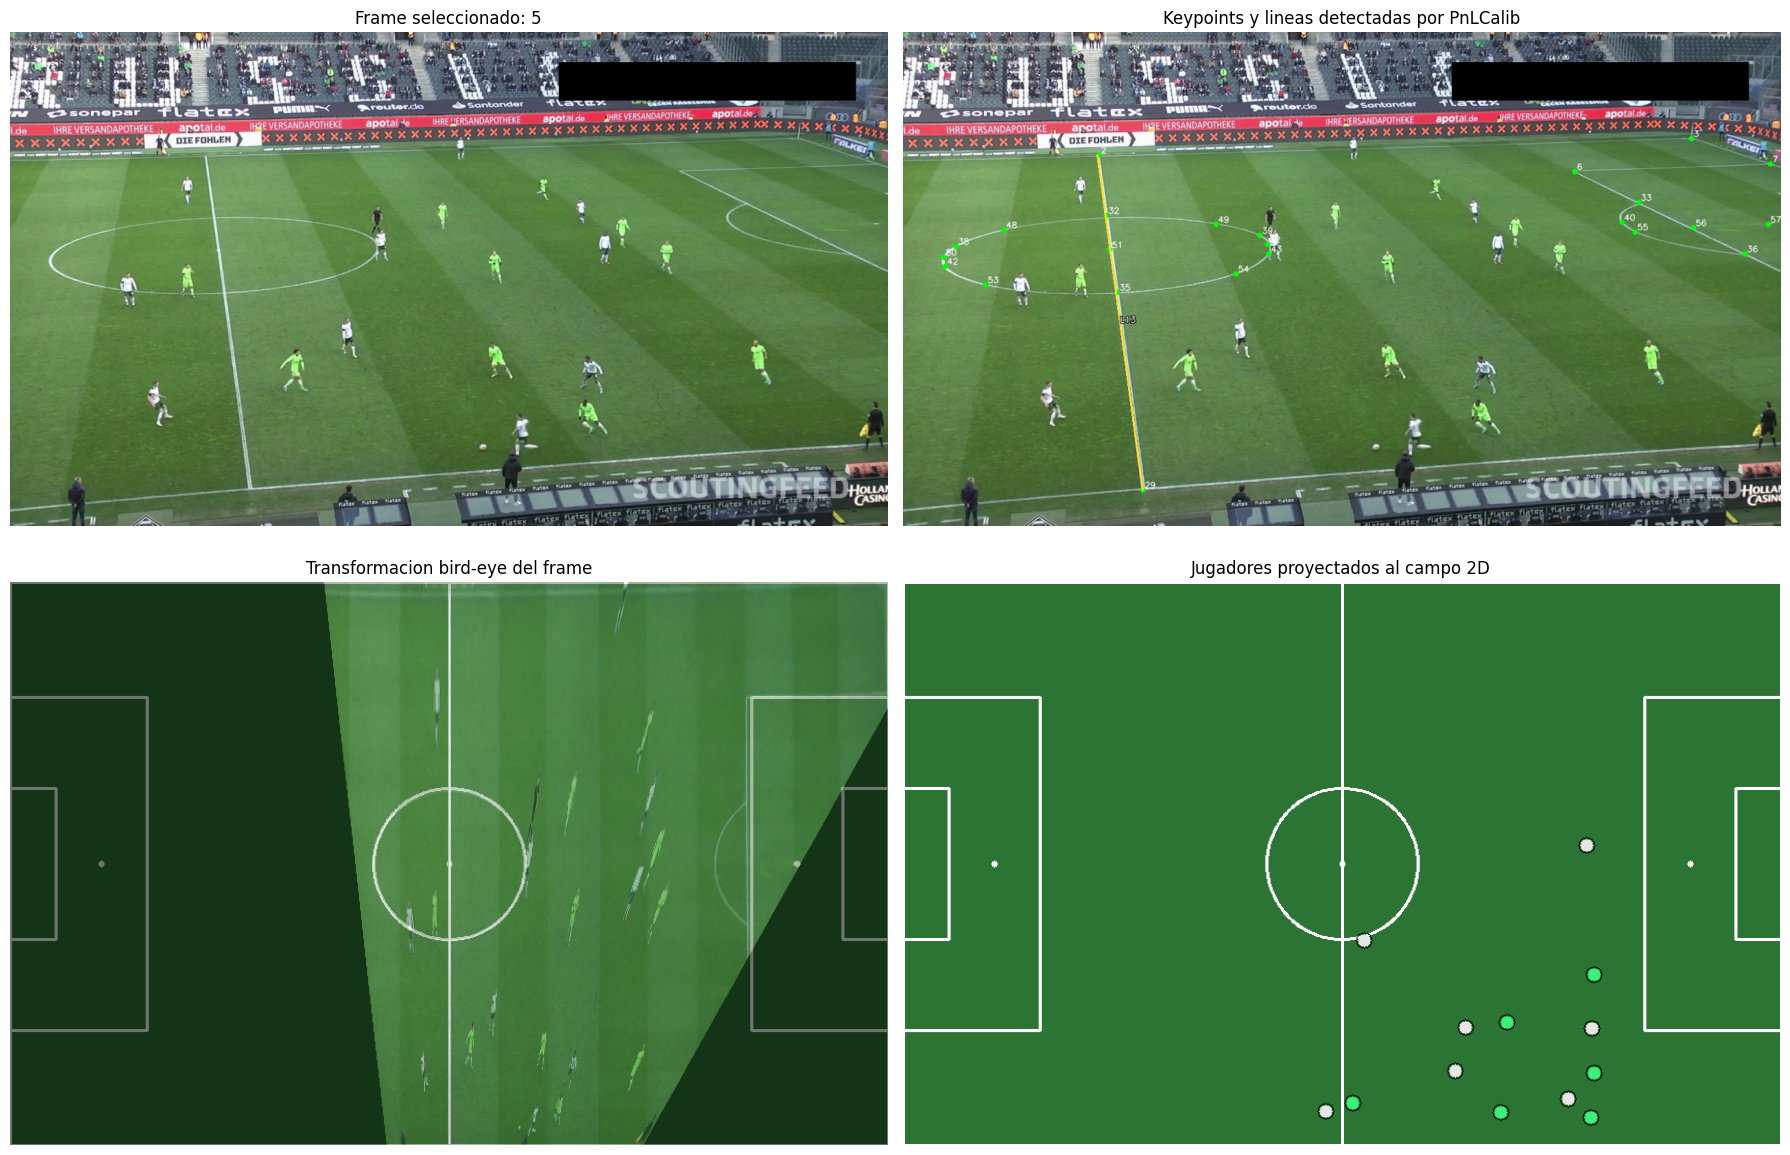

In [5]:
if selected_estimate is None or selected_frame_bgr is None:
    raise RuntimeError("No se ha seleccionado ningun frame.")
if not selected_estimate.has_homography:
    raise RuntimeError("El mejor frame no tiene homografia valida.")

if VISUALIZE_FRAME_INDEX is not None:
    row_df = summary_df.loc[summary_df["frame_index"] == VISUALIZE_FRAME_INDEX]
    if row_df.empty:
        raise ValueError(f"El frame {VISUALIZE_FRAME_INDEX} no esta en el rango procesado.")
    raise NotImplementedError("Para forzar un frame concreto, vuelve a ejecutar el bucle guardando ese estimate explicitamente.")

overlay_bgr = overlay_pnlcalib_detections(selected_frame_bgr, selected_estimate)
warped_bgr = warp_frame_to_birdeye(
    selected_frame_bgr,
    selected_estimate.homography_image_to_template,
    geometry=geometry,
    pixels_per_meter=PIXELS_PER_METER,
)
blended_birdeye = blend_birdeye_with_template(
    warped_bgr,
    geometry=geometry,
    pixels_per_meter=PIXELS_PER_METER,
)

inside_tracks = [track for track in selected_tracks if track["inside_field"]]
inside_field_points = np.array(
    [[track["field_x_m"], track["field_y_m"]] for track in inside_tracks],
    dtype=np.float32,
) if inside_tracks else np.zeros((0, 2), dtype=np.float32)
inside_field_teams = [track.get("team") for track in inside_tracks]
projected_field_rgb = render_projected_tracks_birdeye(
    inside_field_points,
    teams=inside_field_teams,
    geometry=geometry,
    pixels_per_meter=PIXELS_PER_METER,
    background_rgb=blended_birdeye,
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0, 0].imshow(bgr_to_rgb(selected_frame_bgr))
axes[0, 0].set_title(f"Frame seleccionado: {selected_frame_index}")
axes[0, 1].imshow(bgr_to_rgb(overlay_bgr))
axes[0, 1].set_title("Keypoints y lineas detectadas por PnLCalib")
axes[1, 0].imshow(blended_birdeye)
axes[1, 0].set_title("Transformacion bird-eye del frame")
axes[1, 1].imshow(projected_field_rgb)
axes[1, 1].set_title("Jugadores proyectados sobre el bird-eye")
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()

print(f"Visible keypoints: {selected_estimate.visible_keypoints_count}")
print(f"Visible lines: {selected_estimate.visible_lines_count}")
print(f"Reprojection error: {selected_estimate.reprojection_error}")
print(f"Homografia encontrada: {selected_estimate.has_homography}")
print(f"Modo: {selected_estimate.estimation_mode}")
print(f"Tracks proyectados: {len(selected_tracks)}")
print(f"Tracks dentro del campo: {len(inside_tracks)}")


In [6]:
if not selected_tracks:
    print("No hay tracks de jugador/portero/arbitro en ese frame del tracks.json.")
else:
    display(
        pd.DataFrame(selected_tracks)[
            [
                "track_id",
                "class_name",
                "team",
                "field_x_m",
                "field_y_m",
                "inside_field",
            ]
        ].sort_values(by=["inside_field", "class_name", "track_id"], ascending=[False, True, True])
    )


,track_id,class_name,team,field_x_m,field_y_m,inside_field
9,10,player,Real Madrid,80.227165,62.350422,True
10,11,player,Wolfsburgo,72.824448,53.168198,True
11,12,player,Wolfsburgo,83.010681,64.672981,True
15,16,player,Wolfsburgo,83.316338,59.261047,True
16,18,player,Real Madrid,51.045612,63.827820,True
17,19,player,Real Madrid,82.495789,31.742310,True
19,22,player,Real Madrid,83.161049,53.916748,True
3,4,player,Wolfsburgo,54.281536,62.839729,True
4,5,player,Real Madrid,66.601715,59.045071,True
5,6,player,Wolfsburgo,83.319221,47.432552,True
